In [1]:
from cnmodel import populations
from cnmodel.util import sound, random_seed
from cnmodel.protocols import Protocol
from collections import OrderedDict
import os, sys, time
import pickle
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from neuron import h
import multiprocessing as mp
from scipy.signal import savgol_filter
import yaml
import seaborn as sns
import itertools

--No graphics will be displayed.
[722945] Note: detected 128 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[722945] Note: NumExpr detected 128 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[722945] NumExpr defaulting to 16 threads.


## Functions

In [2]:
def get_response_map(levels, freqs, results, baseline, response, cell_type, cell_id):
    
    spont_spikes = 0
    spont_time = 0

    # calculate spontaneous firing rate
    for stim, iterations in list(results.values()):
        
        for vec in list(iterations.values()):
            
            spikes = vec[(cell_type, cell_id)][1]
            spont_spikes += ((spikes >= baseline[0]) * (spikes < baseline[1])).sum()
            spont_time += baseline[1] - baseline[0]

    spont_rate = spont_spikes / spont_time

    nreps = 1

    # calculate response firing rate
    matrix = np.zeros((len(levels), len(freqs)))

    for stim, iteration in list(results.values()):

        for i in range(nreps):

            vec = iteration[i]
            spikes = vec[(cell_type, cell_id)][1]
            n_spikes = ((spikes >= response[0]) & (spikes < response[1])).sum()

            freq = stim.key()['f0']
            level = stim.key()['dbspl']

            j = freqs.index(freq)
            i = levels.index(level)

            matrix[i,j] += n_spikes - spont_rate * (response[1] - response[0])
    
    return matrix

In [3]:
def get_spontaneous_rate(cell_type, results, stimpar, pyr_ids=None):
    spont_spikes = []
    spont_times = []

    for stim, iterations in list(results.values()):
        rep_spont_spikes = []
        for cell, vec in iterations.items():
            if isinstance(cell, str):
                continue
            # save_rate = True if ((cell_type in ['sgc', 'dstellate', 'tuberculoventral']) or (('pyr' in cell_type) and (cell[1] in pyr_ids))) else False
            save_rate = True
            if (cell_type in cell[0]) and save_rate:
                spikes = np.array(vec[1])
                # if len(spikes) > 0:
                rep_spont_spikes.append(((spikes >= stimpar['baseline'][0]) * (spikes < stimpar['baseline'][1])).sum())
                # spont_times.append(stimpar['baseline'][1] - stimpar['baseline'][0])
        spont_spikes.append(rep_spont_spikes)

    spont_spikes = np.mean(spont_spikes, axis=0)

    spont_rates = np.array(spont_spikes) / (stimpar['baseline'][1] - stimpar['baseline'][0])
    return spont_rates

In [4]:
def get_cell_nspikes(cell_type, results, response, pyr_ids=None):
    n_spikes = []
    cell_ids = []

    for stim, iterations in results.values():
        rep_n_spikes = []
        rep_cell_ids = []
        for cell, vec in iterations.items():
            if isinstance(cell, str):
                continue
            # save_rate = True if ((cell_type in ['sgc', 'dstellate', 'tuberculoventral']) or (('pyr' in cell_type) and (cell[1] in pyr_ids))) else False
            save_rate = True
            if (cell_type in cell[0]) and save_rate:
                spikes = np.array(vec[1])
                num_spikes = ((spikes >= response[0]) & (spikes <= response[1])).sum()
                rep_n_spikes.append(num_spikes)
                rep_cell_ids.append(cell[1])

        n_spikes.append(rep_n_spikes)
        cell_ids.append(rep_cell_ids)

    n_spikes = np.mean(n_spikes, axis=0)

    return cell_ids[0], np.array(n_spikes)

In [33]:
def get_evoked_firing_rates(cell_type, results, response, pyr_ids_per_band=None):

    avg_msfs = {}
    cell_ids = {}

    for stim, iterations in list(results.values()):

        stim_avg_msfs  = []
        stim_cell_ids = []

        for cell, vec in iterations.items():
            temp = 6
            # rep_avg_msfs = []

            if isinstance(cell, str):
                continue

            if cell_type in cell[0]:

                cell_id = cell[1]

                spkt = vec[1]
                resp_spkt = spkt[((spkt >= response[0]) & (spkt <= response[1]))]

                num_spikes = len(resp_spkt)
                num_isi = num_spikes - 1 if num_spikes > 0 else 0
                msf = num_isi / (resp_spkt[-1] - resp_spkt[0]) * 1000 if num_spikes > 1 else 1

                stim_cell_ids.append(cell_id)

                stim_avg_msfs.append(msf)
        
        avg_msfs[(stim.opts['f0'], stim.opts['dbspl'])] = np.array(stim_avg_msfs).flatten()
        cell_ids[(stim.opts['f0'], stim.opts['dbspl'])] = np.array(stim_cell_ids).flatten()

    return cell_ids, avg_msfs

## Normal Hearing

In [58]:
stimpar = {
    "dur": 0.26,
    "pip": 0.1,
    "start": [0.1],
    "baseline": [0, 100],
    "response": [100, 200],
}

### Response Maps

In [23]:
results_df = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_6dbs_0if_1cpb_1nreps/results_df.pkl', 'rb'))
pyr_ids_per_band = pickle.load(open('/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_6dbs_0if_1cpb_1nreps/pyramidal_ids_per_band.pkl', 'rb'))

In [24]:
results_od = OrderedDict()
max_iter = 0
stim_order = []
freqs = set()
levels = set()

for k, v in list(results_df.items()):

    f0, dbspl, iteration = k
    max_iter = max(max_iter, iteration)
    stim, result = v
    key = "f0: %0.0f  dBspl: %0.0f" % (f0, dbspl)
    results_od.setdefault(key, [stim,{}])
    results_od[key][1][iteration] = result
    stim_order.append((f0, dbspl))
    freqs.add(f0)
    levels.add(dbspl)

freqs = sorted(list(freqs))
levels = sorted(list(levels))

In [25]:
pyr_freqs = np.array(list(pyr_ids_per_band.keys()))

freq_pyr_ids = {9: pyr_ids_per_band[pyr_freqs[np.argmin(np.abs(pyr_freqs - 9000))]][0],
                13: pyr_ids_per_band[pyr_freqs[np.argmin(np.abs(pyr_freqs - 13000))]][0],
                17: pyr_ids_per_band[pyr_freqs[np.argmin(np.abs(pyr_freqs - 17000))]][0],
                22: pyr_ids_per_band[pyr_freqs[np.argmin(np.abs(pyr_freqs - 22000))]][0],
                30: pyr_ids_per_band[pyr_freqs[np.argmin(np.abs(pyr_freqs - 30000))]][0]}

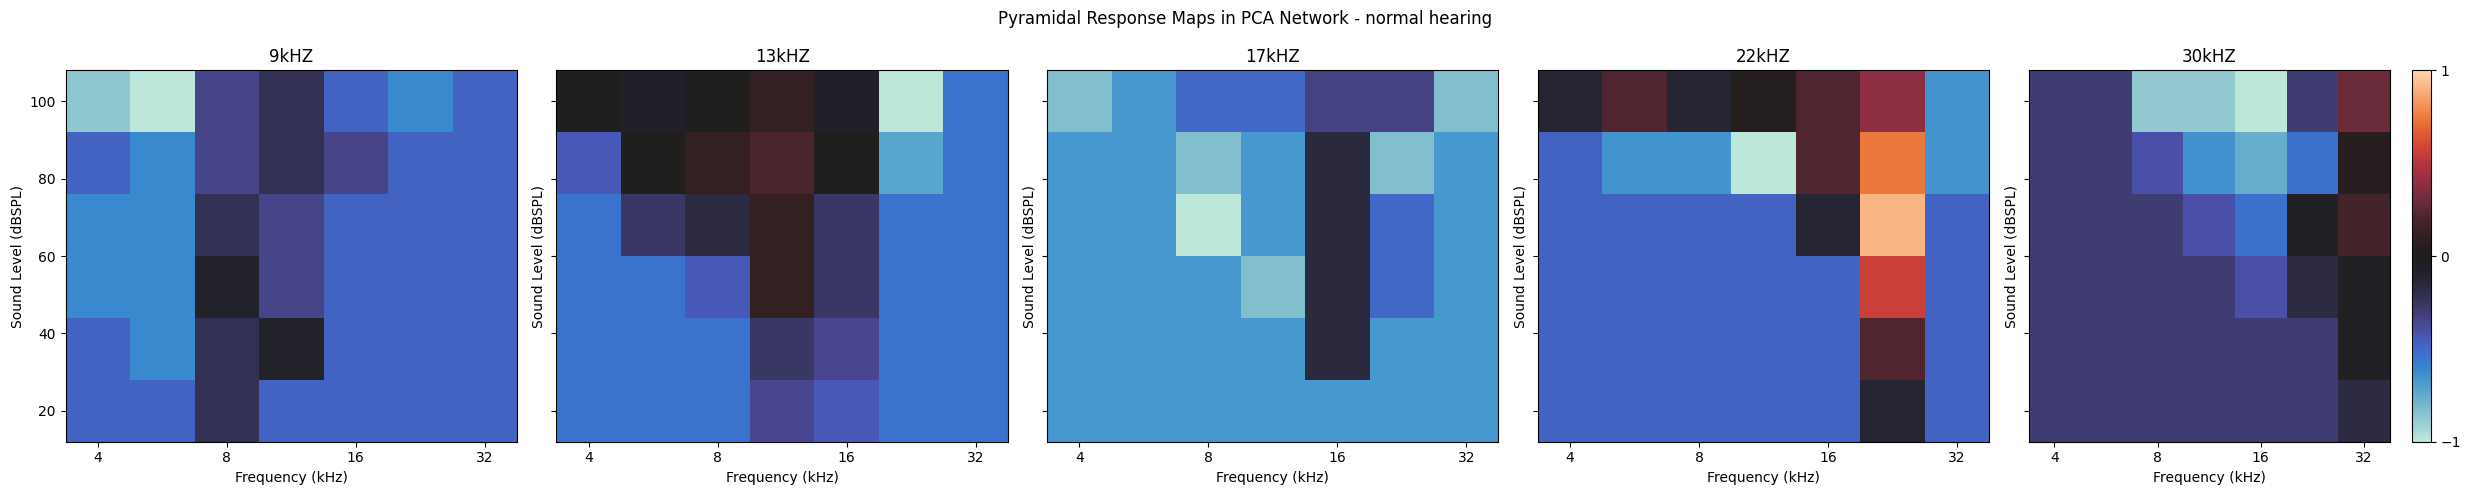

In [26]:
cell_type = 'pyramidal'

fig, axs = plt.subplots(1,len(freq_pyr_ids),figsize=(5*len(freq_pyr_ids),5), sharey=True, sharex=True)
axs = axs.ravel()

for i, pyr_freq in enumerate(freq_pyr_ids):

    cell_id = freq_pyr_ids[pyr_freq]

    b = (freqs[-1] - freqs[0]) / np.log(freqs[-1] / freqs[0])
    a = freqs[0] - b * np.log(freqs[0])
    freqs_log = a + b * np.log(freqs)

    ds_matrix = get_response_map(levels, freqs, results_od, stimpar['baseline'], stimpar['response'], cell_type, cell_id)

    cmap = sns.color_palette("icefire", as_cmap=True)
    # cmap = cm.twilight

    # fig, axs = plt.subplots(1,1,figsize=(5,4))  #, layout='constrained')

    # matrix = data_norm['matrix']
    # matrix_norm = 2*((matrix - np.min(matrix))/(np.max(matrix) - np.min(matrix))) - 1
    matrix_norm = ds_matrix / np.max(np.abs(ds_matrix))
    im = axs[i].pcolormesh(freqs_log, levels, matrix_norm, cmap=cmap, vmin=-1, vmax=1) 
    axs[i].set_title('Normal')
    axs[i].set_ylabel('Sound Level (dBSPL)')
    axs[i].set_xticks([freqs_log[i] for i in [0, 2, 4, 6]])
    axs[i].set_xticklabels([4, 8, 16, 32])

    # title = 'Hearing Loss' if 'loss' in self.hearing else 'Normal Hearing'
    axs[i].set_title(f'{pyr_freq}kHZ')
    axs[i].set_xlabel('Frequency (kHz)')

fig.suptitle('Pyramidal Response Maps in PCA Network - normal hearing')
fig.colorbar(im, ticks=[-1,0,1])
# fig.set_dpi(200)
fig.tight_layout()
# fig.savefig('dstellate-response_map.png', dpi=300)
# fig.savefig('dstellate-response_map.pdf', dpi=300)

### Evoked Firing

In [15]:
freq = 22000
level = 60
results_df = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_2dbs_{level}dB_{freq}if_1cpb_1nreps/results_df.pkl', 'rb'))
pyr_ids_per_band = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_2dbs_{level}dB_{freq}if_1cpb_1nreps/pyramidal_ids_per_band.pkl', 'rb'))

In [16]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')

In [60]:
colors = {'pyramidal': 'tab:blue',
          'vertical': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

In [ ]:
pyr_ids = list(itertools.chain.from_iterable(pyr_ids_per_band.values()))
freqs = list(pyr_ids_per_band.keys())


pyr_ids, pyr_rates = get_evoked_firing_rates('pyramidal', results_df, stimpar['response'])
ds_ids, ds_rates = get_evoked_firing_rates('dstellate', results_df, stimpar['response'])
vert_ids, vert_rates = get_evoked_firing_rates('tuberculoventral', results_df, stimpar['response'])
sgc_ids, sgc_rates = get_evoked_firing_rates('sgc', results_df, stimpar['response'])

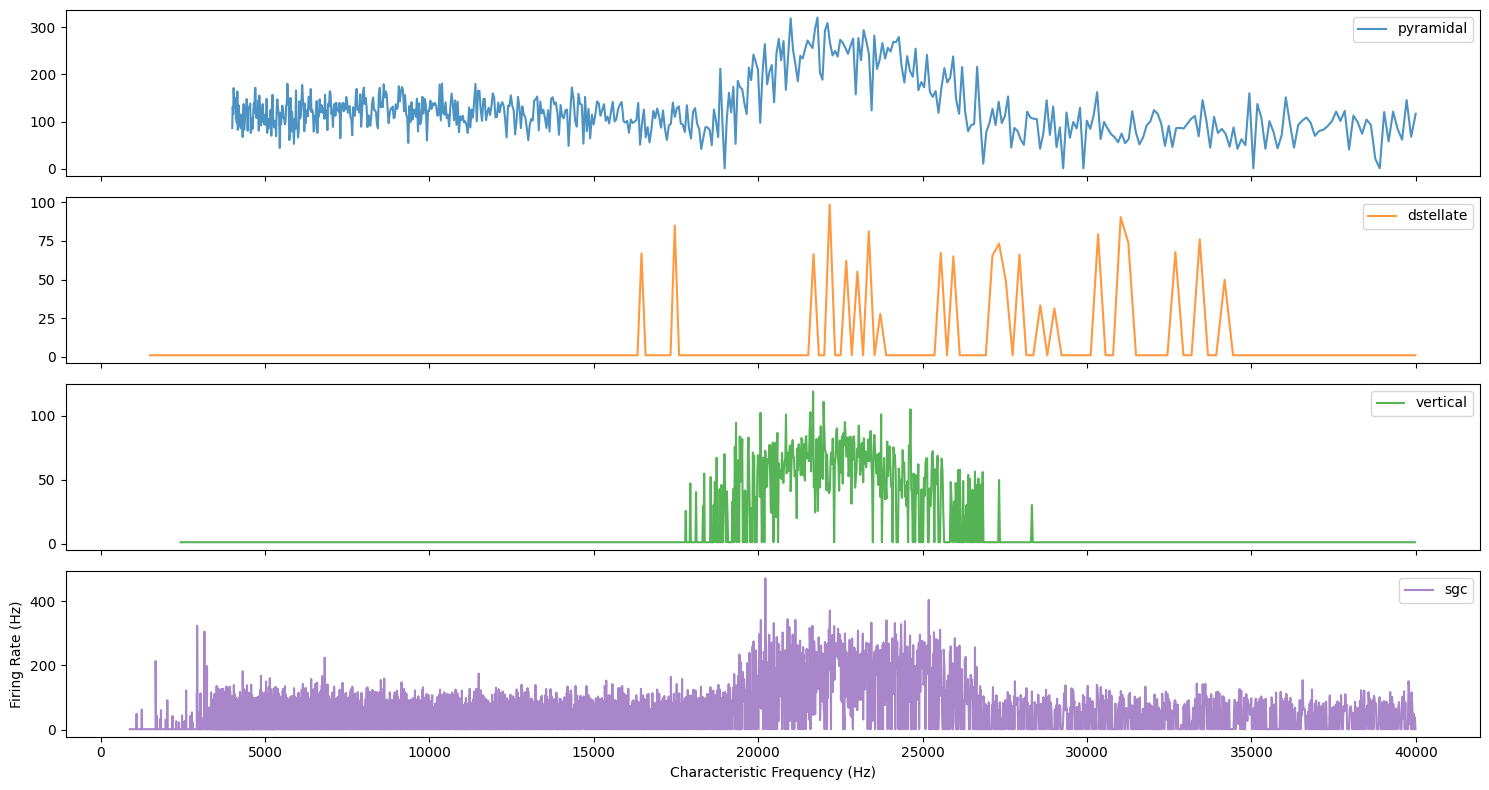

In [61]:
fig, axs = plt.subplots(4,1,figsize=(15,8), sharex=True)  #, sharey=True)
axs = axs.ravel()

axs[0].plot(freqs, pyr_rates[(freq, level)], color=colors['pyramidal'], zorder=13, alpha=0.8, label='pyramidal')
axs[0].legend(loc='upper right')

axs[1].plot(ds_cfs[ds_ids[(freq, level)]], ds_rates[(freq, level)], color=colors['dstellate'], zorder=13, alpha=0.8, label='dstellate')
axs[1].legend(loc='upper right')

axs[2].plot(vert_cfs[vert_ids[(freq, level)]], vert_rates[(freq, level)], color=colors['vertical'], zorder=13, alpha=0.8, label='vertical')
axs[2].legend(loc='upper right')

axs[3].plot(sgc_cfs[sgc_ids[(freq, level)]], sgc_rates[(freq, level)], color=colors['sgc'], zorder=13, alpha=0.8, label='sgc')
axs[3].legend(loc='upper right')

axs[-1].set_xlabel('Characteristic Frequency (Hz)')
axs[-1].set_ylabel('Firing Rate (Hz)')

fig.tight_layout()

### PSTH

In [40]:
freq = 22000
level = 60
results_df = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_2dbs_{level}dB_{freq}if_1cpb_1nreps/results_df.pkl', 'rb'))
pyr_ids_per_band = pickle.load(open(f'/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-III-ohc_1.0-ihc_1.0-SPx0.00044_VPx0.0006/665cfs_2dbs_{level}dB_{freq}if_1cpb_1nreps/pyramidal_ids_per_band.pkl', 'rb'))

In [41]:
results_od = OrderedDict()
max_iter = 0
stim_order = []
freqs = set()
levels = set()

for k, v in list(results_df.items()):

    f0, dbspl, iteration = k
    max_iter = max(max_iter, iteration)
    stim, result = v
    key = "f0: %0.0f  dBspl: %0.0f" % (f0, dbspl)
    results_od.setdefault(key, [stim,{}])
    results_od[key][1][iteration] = result
    stim_order.append((f0, dbspl))
    freqs.add(f0)
    levels.add(dbspl)

freqs = sorted(list(freqs))
levels = sorted(list(levels))

In [49]:
cell_types = ['pyramidal','tuberculoventral', 'dstellate', 'sgc']

colors = {'pyramidal': 'tab:blue',
          'tuberculoventral': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

cell_ids = {cell_type: [] for cell_type in cell_types}
cell_spikes = {cell_type: [] for cell_type in cell_types}

single_cell_ids = {'pyramlidal': 2341,
                   'dstellate': 502,
                   'tuberucloventral': 3831,
                   'sgc': 7810}

cell_count = 0
trials = results_od[f'f0: {freq}  dBspl: {level}'][1]

for trial, cells in trials.items():
    for vec in cells.items():
        temp = 7
        if isinstance(vec[0], str):
            t = vec[1]
            continue

        cell_type = vec[0][0]
        cell_id = vec[0][1]
        spikes = vec[1][1]

        if 'pyr' in cell_type:
            pyr_trace = vec[1][0]

        if cell_type in single_cell_ids.keys():
            if cell_id == single_cell_ids[cell_type]:
                cell_ids[cell_type].append(cell_id)
                cell_spikes[cell_type].append(spikes)
        else:
            cell_ids[cell_type].append(cell_id)
            cell_spikes[cell_type].append(spikes)

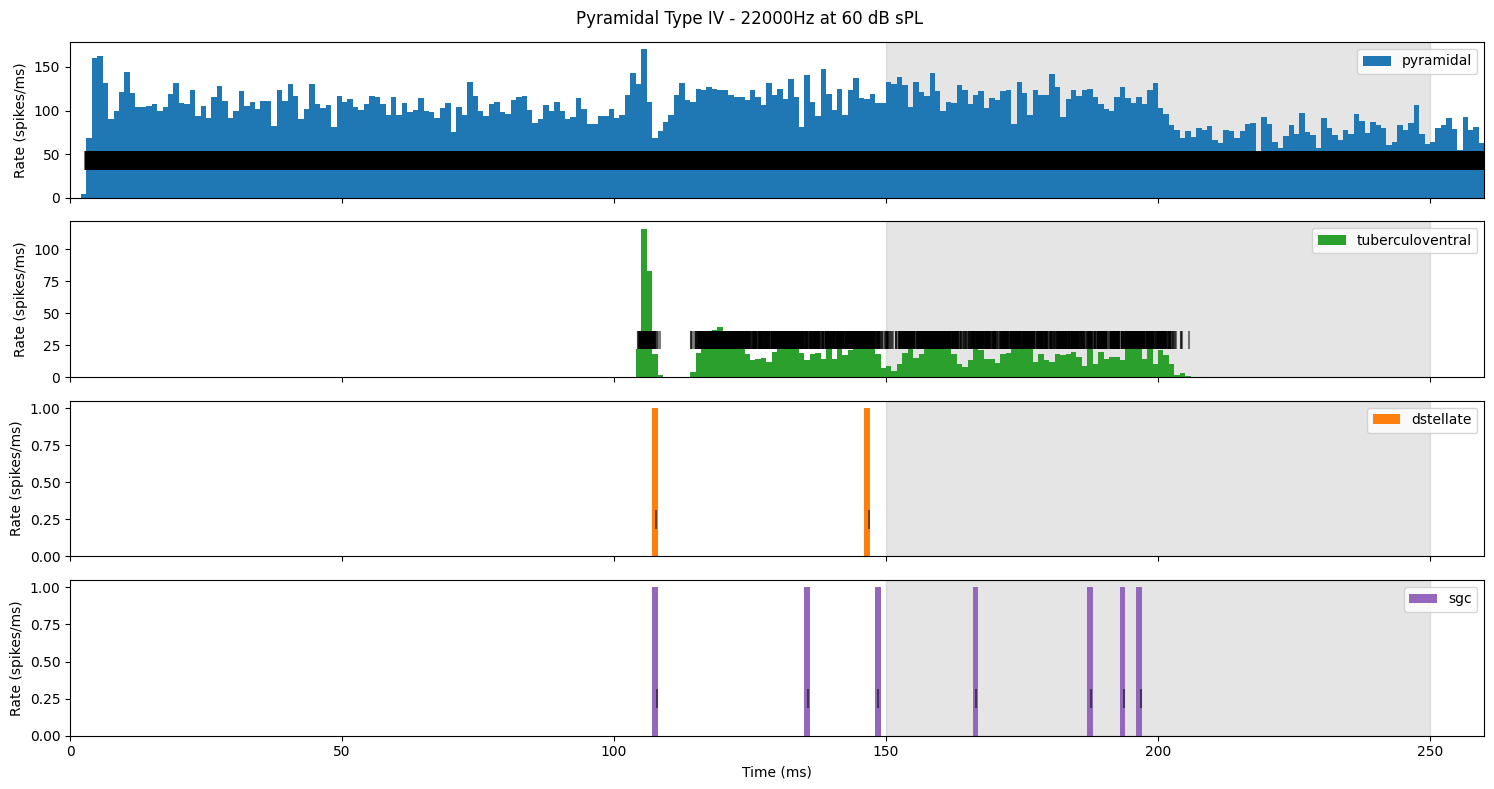

In [52]:
fig, axs = plt.subplots(len(cell_types), 1, figsize=(15,8), sharex=True, sharey=False)
axs = axs.ravel() 

for i, cell_type in enumerate(cell_types):

    cell_spike_times = np.concatenate(cell_spikes[cell_type])

    bin_size = 0.001  # 1 ms
    bins = np.arange(0, stimpar['dur']+bin_size, bin_size)

    counts, edges = np.histogram(cell_spike_times / 1000, bins=bins)

    psth = counts * (bin_size * 1000)  # spikes / s
    bin_centers = edges[:-1] + bin_size / 2

    axs[i].axvspan(stimpar['response'][0]/1000, stimpar['response'][1]/1000, color='grey', alpha=0.2)

    axs[i].bar(bin_centers, psth, width=bin_size, color=colors[cell_type], label=cell_type)

    axs[i].eventplot(cell_spike_times/1000, lineoffsets=psth.max()/4, linelengths=psth.max()/8, color='k', alpha=0.5)

    axs[i].set_ylabel('Rate (spikes/ms)')

    locs = axs[i].get_xticks()
    axs[i].set_xticks(locs)
    axs[i].set_xticklabels([int(loc*1000) for loc in locs])
    axs[i].set_xlim([0,(stimpar['dur'])])

    axs[i].legend(loc='upper right')

    # axs[i].set_title(cell_type)

axs[-1].set_xlabel('Time (ms)')

fig.suptitle(f'Pyramidal Type IV - {freq }Hz at {level} dB sPL')
fig.tight_layout()
# fig.savefig(f'SPC_PSTH-{freq}Hz_{level}dB-{resp_type}.png', dpi=300)

## Hearing Loss

In [ ]:
sgc_pop = populations.SGC()
pyr_pop = populations.Pyramidal()
ds_pop = populations.DStellate()
vert_pop = populations.Tuberculoventral()

sgc_cfs = sgc_pop._get_cf_array(species='mouse')
pyr_cfs = pyr_pop._get_cf_array(species='mouse')
ds_cfs = ds_pop._get_cf_array(species='mouse')
vert_cfs = vert_pop._get_cf_array(species='mouse')

In [62]:
colors = {'pyramidal': 'tab:blue',
          'vertical': 'tab:green',
          'dstellate': 'tab:orange',
          'sgc': 'tab:purple'}

In [53]:
batch_dir = '/data/scrook/dcnmodel_scratch/output/response_maps-network_resp_map-IV-batch_ohcs_ihcs-SPx0.00038_VPx0.0039_13000loss-hc/665cfs_1dbs_60dB_22000if_1cpb_1nreps'

In [54]:
cohcs = []
cihcs = []

for subdir in os.scandir(batch_dir):
    
    if subdir.is_dir():
    
        # TODO: get all ohc/ihc combinations

        subdir_name = subdir.name

        for hc_par in subdir_name.split('-'):

            if 'ohc' in hc_par:
                cohcs.append(float(hc_par.split('_')[-1]))
            else:
                cihcs.append(float(hc_par.split('_')[-1]))

cohcs = np.unique(cohcs)
cihcs = np.unique(cihcs)

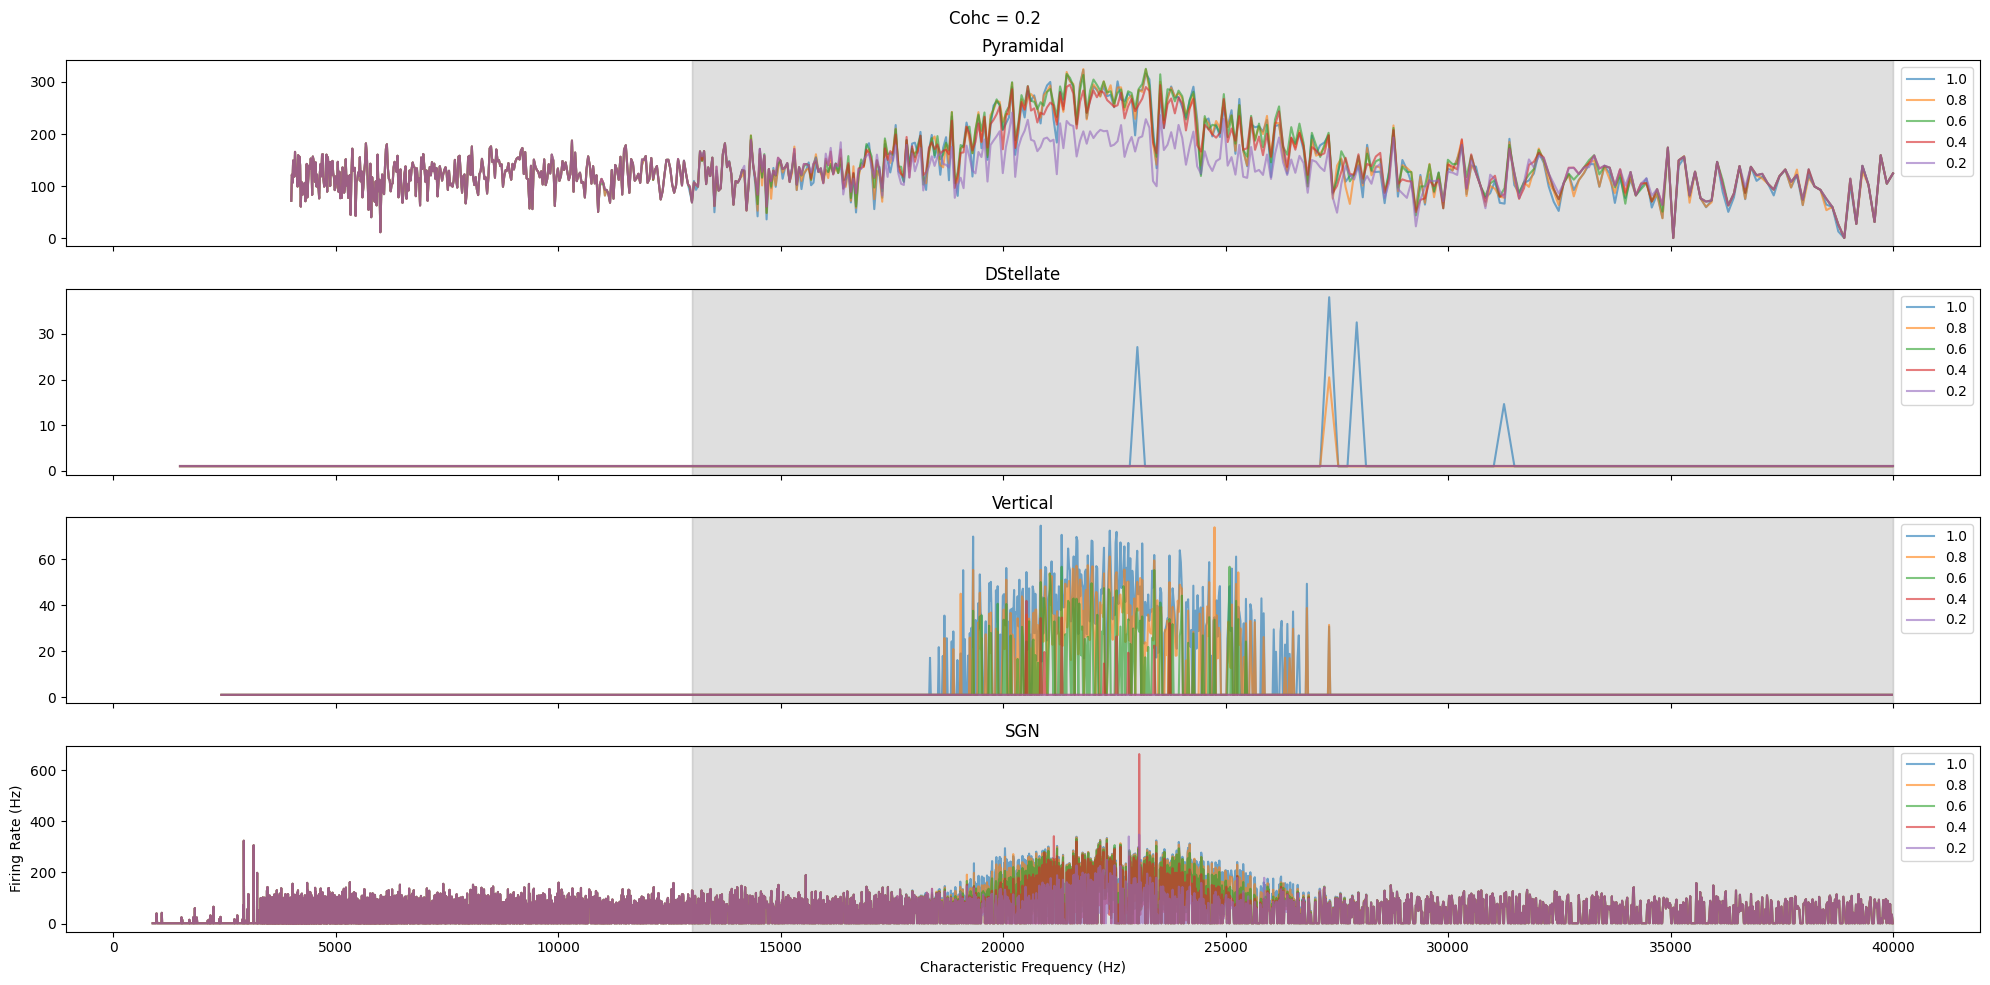

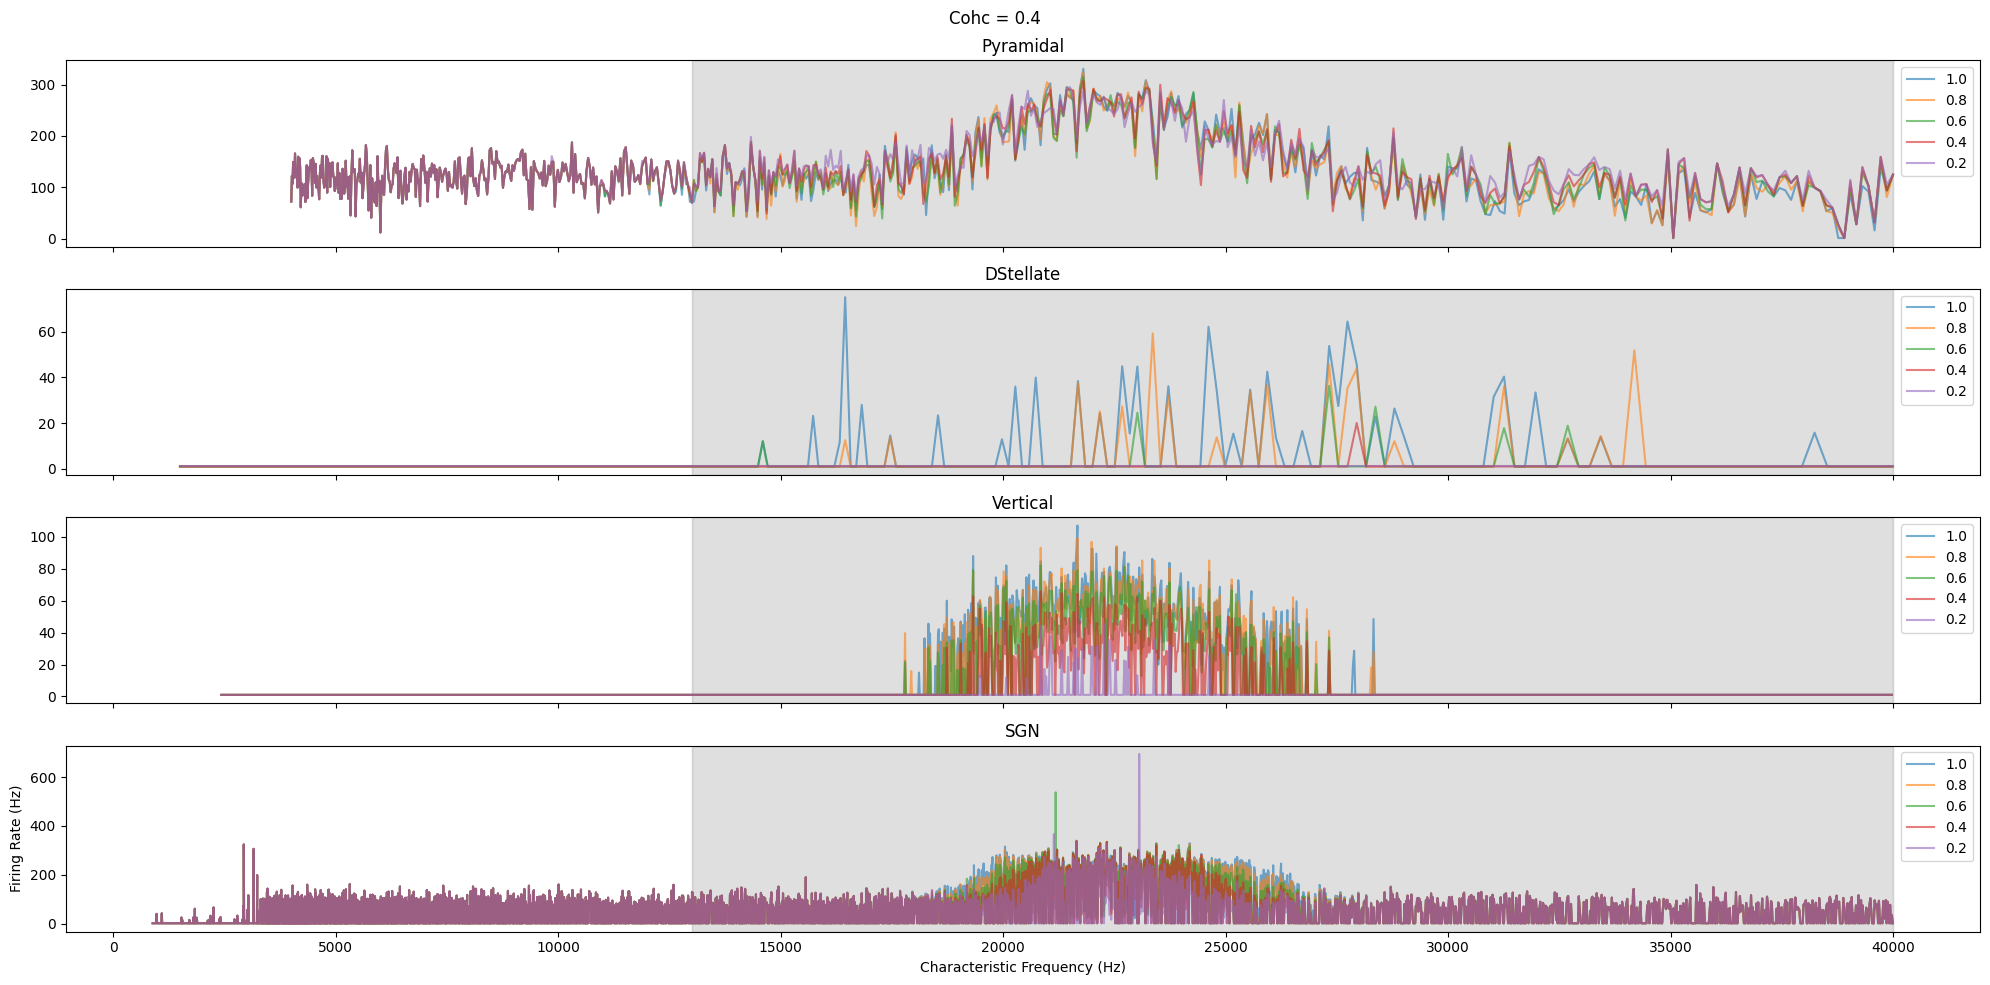

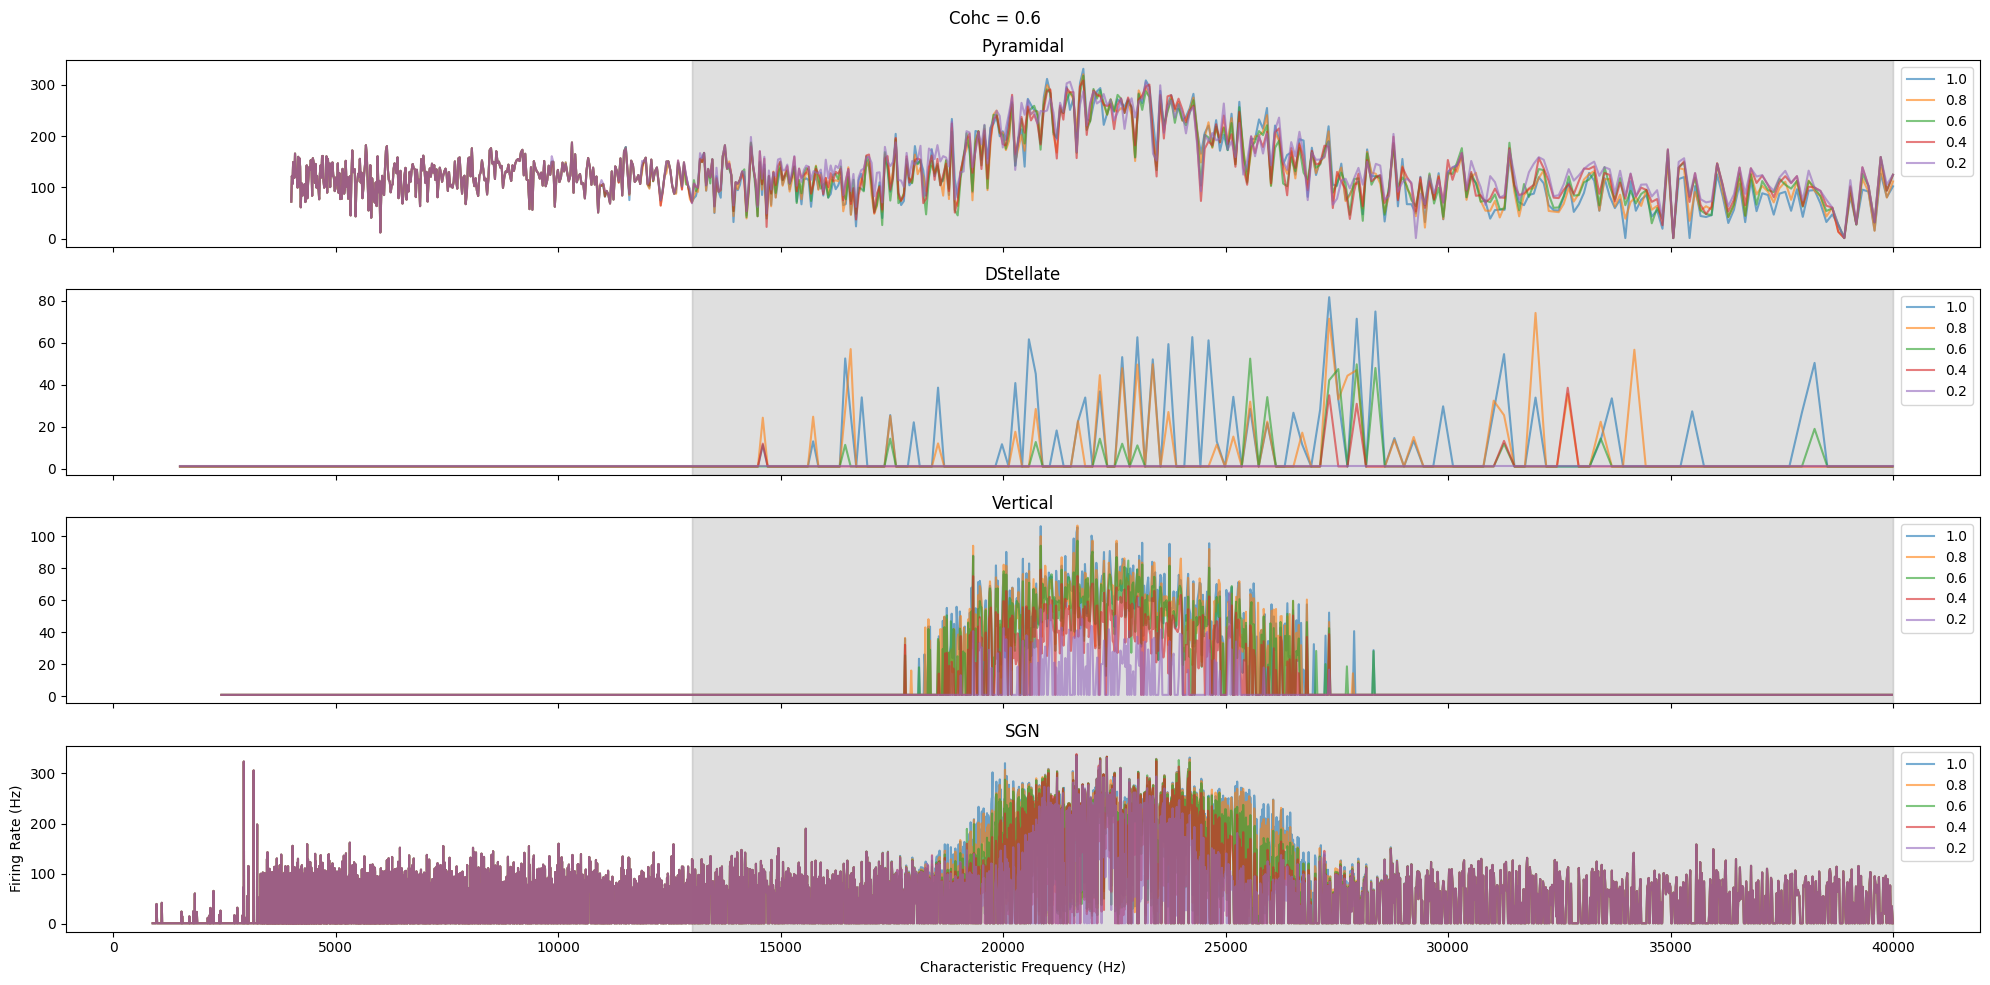

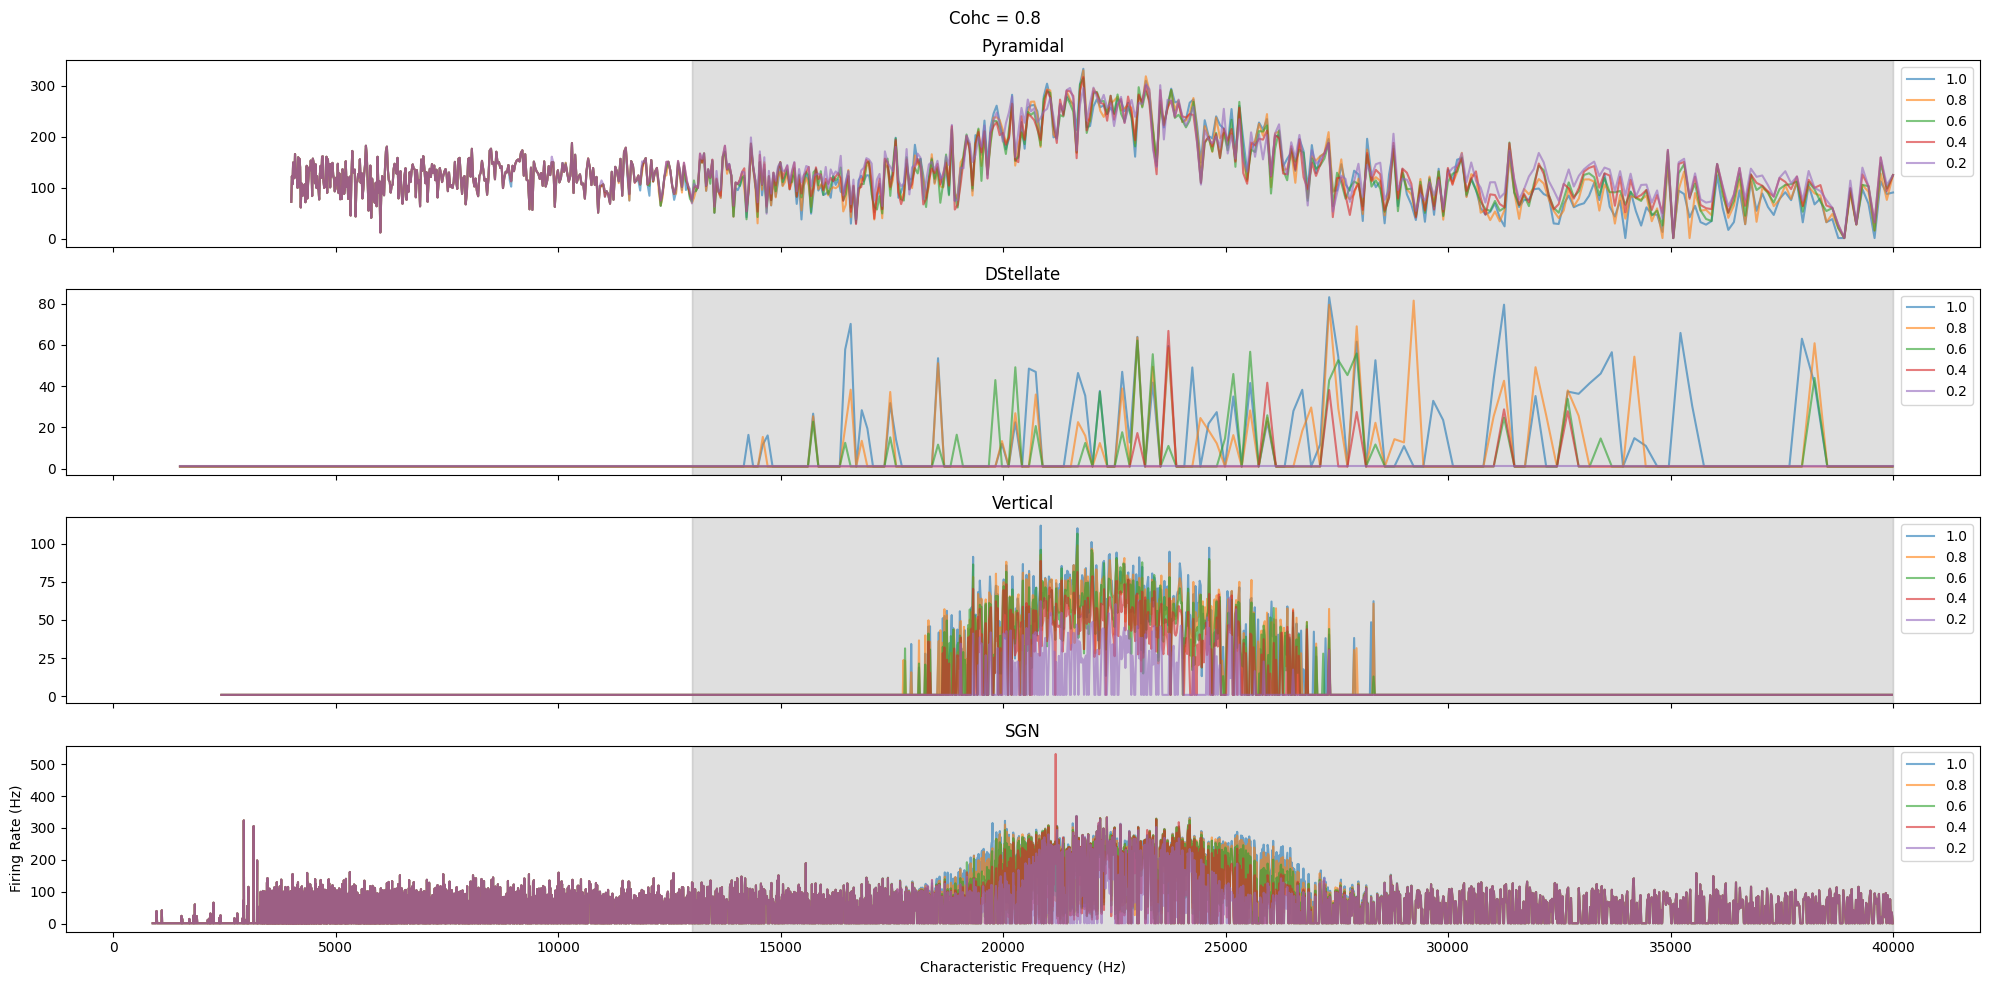

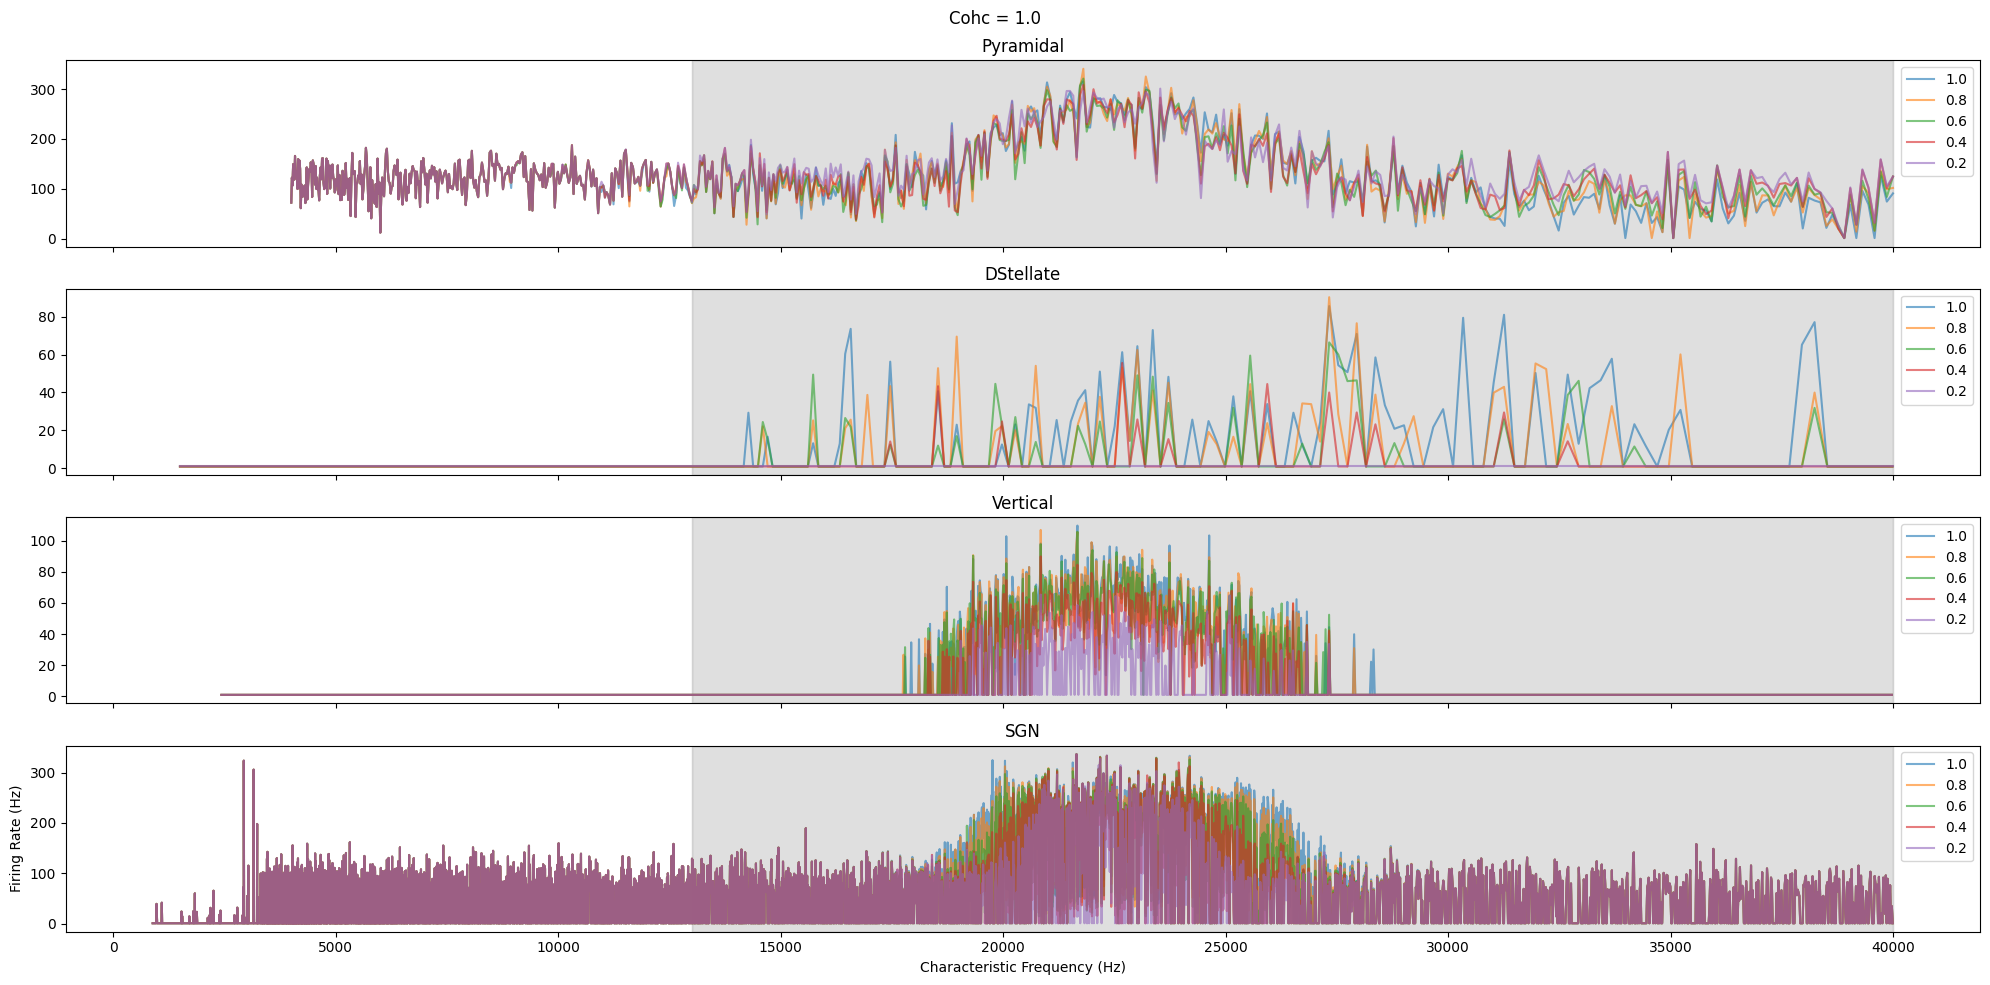

In [79]:
for i, cohc in enumerate(cohcs):

    fig, axs = plt.subplots(4,1, figsize=(20,10), sharex=True)
    axs = axs.ravel()

    for cihc in np.flip(cihcs):

        combo_dir = os.path.join(batch_dir, f'ohc_{cohc}-ihc_{cihc}')

        results_df = pickle.load(open(os.path.join(combo_dir,'results_df.pkl'), 'rb'))
        pyr_ids_per_band = pickle.load(open(os.path.join(combo_dir, 'pyramidal_ids_per_band.pkl'), 'rb'))

        pyr_ids = list(itertools.chain.from_iterable(pyr_ids_per_band.values()))
        freqs = list(pyr_ids_per_band.keys())

        pyr_ids, pyr_rates = get_evoked_firing_rates('pyramidal', results_df, stimpar['response'])
        ds_ids, ds_rates = get_evoked_firing_rates('dstellate', results_df, stimpar['response'])
        vert_ids, vert_rates = get_evoked_firing_rates('tuberculoventral', results_df, stimpar['response'])
        sgc_ids, sgc_rates = get_evoked_firing_rates('sgc', results_df, stimpar['response'])

       
        axs[0].plot(freqs, ( pyr_rates[(freq, level)]), zorder=13, alpha=0.6, label=cihc)
        axs[0].set_title('Pyramidal')
        axs[0].legend(loc='upper right')

        axs[1].plot(ds_cfs[ds_ids[(freq, level)]], ds_rates[(freq, level)], zorder=13, alpha=0.6, label=cihc)
        axs[1].set_title('DStellate')
        axs[1].legend(loc='upper right')

        axs[2].plot(vert_cfs[vert_ids[(freq, level)]], vert_rates[(freq, level)], zorder=13, alpha=0.6, label=cihc)
        axs[2].set_title('Vertical')
        axs[2].legend(loc='upper right')

        axs[3].plot(sgc_cfs[sgc_ids[(freq, level)]], sgc_rates[(freq, level)], zorder=13, alpha=0.6, label=cihc)
        axs[3].set_title('SGN')
        axs[3].legend(loc='upper right')

        axs[-1].set_xlabel('Characteristic Frequency (Hz)')
        axs[-1].set_ylabel('Firing Rate (Hz)')

        for ax in axs:
            ax.axvspan(xmin=13000, xmax=40000, color='grey', zorder=1, alpha=0.05)

    fig.suptitle(f'Cohc = {cohc}')

    fig.tight_layout()



In [ ]:
# TODO: spike trains in cochlea for each hair cell impairment combination

In [63]:
# TODO: heatmap for each cell type

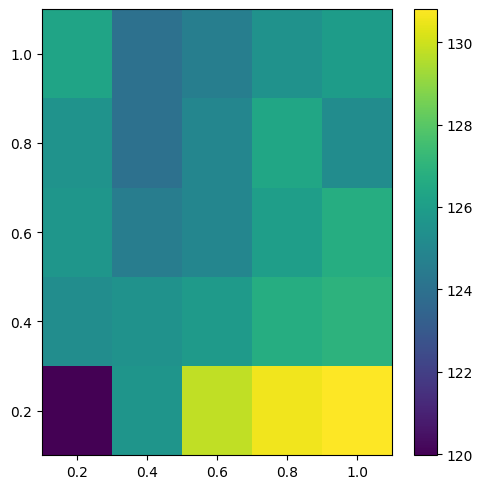

In [33]:
fig, axs = plt.subplots(1,1, figsize=(5,5))
# axs = axs.ravel()

avg_rates = []

for i, cohc in enumerate(cohcs):

    cohc_avg_rates = []

    for cihc in cihcs:

        combo_dir = os.path.join(batch_dir, f'ohc_{cohc}-ihc_{cihc}')

        stim_avg_rates = list(pickle.load(open(os.path.join(combo_dir, 'stim_avg_rates.pkl'), 'rb')).values())[0]
        avg_rate = np.average(stim_avg_rates)
        cohc_avg_rates.append(avg_rate)

        # axs[i].plot(freqs, stim_avg_rates, label=cihc)
    
    avg_rates.append(cohc_avg_rates)

    # axs[i].set_title(f'Cohc = {cohc}')
    # axs[i].legend(loc='upper right', title='Cihc')

im = axs.pcolormesh(cihcs, cohcs, np.array(avg_rates))
fig.colorbar(im)
fig.tight_layout()

